# 01. Does the heart work?

This notebook is the readable companion to `tests/test_validation.py`, which is the
authority. Nothing here asserts anything the test suite does not; the point is to *look*
at the beat rather than to trust a green tick.

Run `make validate` first, or just execute this notebook, which computes the table itself.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hcmtwin import (HCM_GEOMETRY, HCM_MATERIAL, HEALTHY_GEOMETRY, HEALTHY_MATERIAL,
                     RESTING_LOADING, observe, simulate)
from hcmtwin.validation import validation_rows
from hcmtwin.viz import style

style.apply()
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)

## The gates

In [2]:
table = validation_rows()
print(f"{int(table['pass'].sum())} of {len(table)} gates pass")
failures = table[~table["pass"]]
display(failures if len(failures) else table.head(12))

35 of 35 gates pass


,gate,quantity,value,units,target,pass,note
0,healthy baseline,ejection_fraction,0.6584,fraction,0.55 to 0.7,True,
1,healthy baseline,edv_ml,112.9699,mL,110 to 130,True,
2,healthy baseline,stroke_volume_ml,74.3824,mL,65 to 75,True,
3,healthy baseline,peak_lv_pressure_mmhg,110.7581,mmHg,110 to 130,True,
4,healthy baseline,end_diastolic_pressure_mmhg,9.5774,mmHg,5 to 12,True,
5,healthy baseline,mean_arterial_pressure_mmhg,94.9093,mmHg,85 to 95,True,
6,healthy baseline,cardiac_output_l_per_min,4.8456,L/min,4.5 to 5.5,True,
7,healthy baseline,wall_thickness_cm,0.9245,cm,0.6 to 1.1,True,
8,healthy baseline,not obstructive,1.0000,boolean,true,True,peak gradient 7.1 mmHg
9,healthy baseline,steady state reached,1.0000,boolean,true,True,6 beats


## The beat itself

Three loops from the same equations. Only myosin availability, passive stiffness and wall
volume differ between them; nothing writes down an ejection fraction.

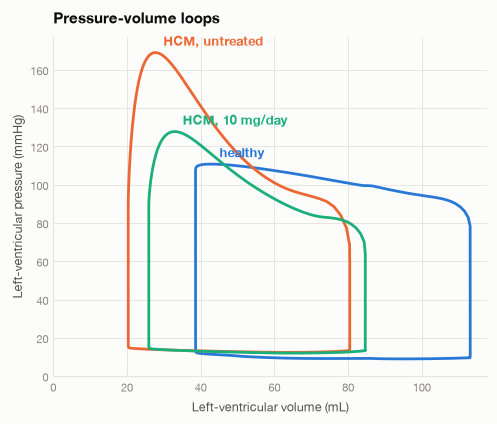

In [3]:
runs = {
    "healthy": (HEALTHY_GEOMETRY, HEALTHY_MATERIAL, 0.0),
    "HCM, untreated": (HCM_GEOMETRY, HCM_MATERIAL, 0.0),
    "HCM, 10 mg/day": (HCM_GEOMETRY, HCM_MATERIAL, 10.0),
}
traces = {}
figure, ax = plt.subplots(figsize=(5.6, 4.4))
for (label, (geom, mat, dose)), colour in zip(runs.items(), style.SERIES):
    result = simulate(geom, mat, RESTING_LOADING, dose, record_trace=True)
    traces[label] = (result, geom)
    t = result.trace
    v = np.append(t.cavity_volume_ml, t.cavity_volume_ml[0])
    p = np.append(t.lv_pressure_mmhg, t.lv_pressure_mmhg[0])
    ax.plot(v, p, color=colour, label=label)
    ax.annotate(label, (v[int(np.argmax(p))], p.max()), xytext=(6, 5),
                textcoords="offset points", color=colour, fontsize=9, fontweight="bold")
ax.set_xlabel("Left-ventricular volume (mL)")
ax.set_ylabel("Left-ventricular pressure (mmHg)")
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.set_title("Pressure-volume loops")
plt.show()

## What each patient reports

In [4]:
rows = []
for label, (result, geom) in traces.items():
    o = observe(result, geom, RESTING_LOADING)
    rows.append({
        "patient": label,
        "EF": round(o.ejection_fraction, 3),
        "EDV (mL)": round(o.edv_ml, 1),
        "ESV (mL)": round(o.esv_ml, 1),
        "SV (mL)": round(o.stroke_volume_ml, 1),
        "EDP (mmHg)": round(o.end_diastolic_pressure_mmhg, 1),
        "gradient (mmHg)": round(o.peak_lvot_gradient_mmhg, 1),
        "wall (cm)": round(o.wall_thickness_cm, 2),
        "E/e'": round(o.e_over_e_prime, 1),
        "strain": round(o.peak_strain_amplitude, 3),
        "ATP/work": round(o.atp_cost_per_stroke_work, 0),
    })
display(pd.DataFrame(rows))

,patient,EF,EDV (mL),ESV (mL),SV (mL),EDP (mmHg),gradient (mmHg),wall (cm),E/e',strain,ATP/work
0,healthy,0.658,113.0,38.6,74.4,9.6,7.1,0.92,7.3,0.209,572.0
1,"HCM, untreated",0.747,80.4,20.3,60.1,13.3,76.1,1.59,10.8,0.154,1173.0
2,"HCM, 10 mg/day",0.694,84.6,25.9,58.7,13.3,36.6,1.56,10.8,0.145,1046.0


### The finding worth pausing on

Give the HCM **geometry** healthy **material** and the ejection fraction is *higher* than
the diseased reference. Wall thickening alone raises ejection fraction, which is why a
reassuring ejection fraction in a thick-walled ventricle is close to uninformative. What
the wall alone does not produce is the elevated filling pressure or the energy cost.

In [5]:
benign = observe(simulate(HCM_GEOMETRY, HEALTHY_MATERIAL, RESTING_LOADING, 0.0),
                 HCM_GEOMETRY, RESTING_LOADING)
diseased = observe(simulate(HCM_GEOMETRY, HCM_MATERIAL, RESTING_LOADING, 0.0),
                   HCM_GEOMETRY, RESTING_LOADING)
comparison = pd.DataFrame({
    "thick wall, healthy tissue": [benign.ejection_fraction,
                                   benign.end_diastolic_pressure_mmhg,
                                   benign.e_over_e_prime,
                                   benign.atp_cost_per_stroke_work],
    "thick wall, HCM tissue": [diseased.ejection_fraction,
                               diseased.end_diastolic_pressure_mmhg,
                               diseased.e_over_e_prime,
                               diseased.atp_cost_per_stroke_work],
}, index=["ejection fraction", "filling pressure (mmHg)", "E/e' surrogate", "ATP per unit work"])
display(comparison.round(2))

,"thick wall, healthy tissue","thick wall, HCM tissue"
ejection fraction,0.76,0.75
filling pressure (mmHg),8.95,13.34
E/e' surrogate,9.22,10.81
ATP per unit work,687.74,1172.81


## Within-beat waveforms

Worth a look because the pressure-volume loop hides the timing. Note that the myosin
populations move within the beat: the parked pool is drawn down during ejection by
force-dependent recruitment and refills in diastole.

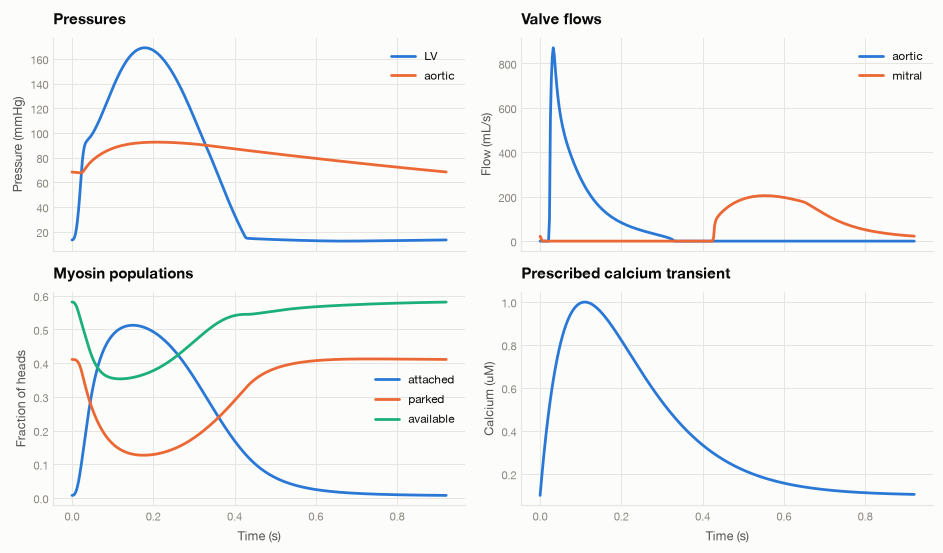

S + D + A departs from 1 by at most 6.66e-16


In [6]:
result, _ = traces["HCM, untreated"]
t = result.trace
figure, axes = plt.subplots(2, 2, figsize=(9.5, 5.6), sharex=True)
axes[0, 0].plot(t.time_s, t.lv_pressure_mmhg, color=style.SERIES[0], label="LV")
axes[0, 0].plot(t.time_s, t.arterial_pressure_mmhg, color=style.SERIES[1], label="aortic")
axes[0, 0].set_ylabel("Pressure (mmHg)"); axes[0, 0].legend(); axes[0, 0].set_title("Pressures")
axes[0, 1].plot(t.time_s, t.aortic_flow_ml_per_s, color=style.SERIES[0], label="aortic")
axes[0, 1].plot(t.time_s, t.mitral_flow_ml_per_s, color=style.SERIES[1], label="mitral")
axes[0, 1].set_ylabel("Flow (mL/s)"); axes[0, 1].legend(); axes[0, 1].set_title("Valve flows")
axes[1, 0].plot(t.time_s, t.attached, color=style.SERIES[0], label="attached")
axes[1, 0].plot(t.time_s, t.parked, color=style.SERIES[1], label="parked")
axes[1, 0].plot(t.time_s, t.available, color=style.SERIES[2], label="available")
axes[1, 0].set_ylabel("Fraction of heads"); axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].legend(); axes[1, 0].set_title("Myosin populations")
axes[1, 1].plot(t.time_s, t.calcium_um, color=style.SERIES[0])
axes[1, 1].set_ylabel("Calcium (uM)"); axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_title("Prescribed calcium transient")
plt.tight_layout(); plt.show()
print("S + D + A departs from 1 by at most "
      f"{float(result.summary.population_error):.2e}")